# Model Comparison — Controlled Study

Systematic evaluation of how **volatility dynamics** and **tail shape** independently affect risk estimates. This is notebook **1 of 3** in the deep-dive series:

1. **`model_comparison.ipynb`** ← *you are here* — controlled comparisons isolating tail and vol effects, 3-tier head-to-head, seed robustness, MS-GARCH parameter inspection.
2. **`validation_backtesting.ipynb`** — non-MC cross-checks (EVT, XGBoost) and rolling-window backtest of the 3 tiers.
3. **`model_diagnosis.ipynb`** — why MS-GARCH fails the backtest despite producing the deepest VaR; failure-mode taxonomy; overall conclusions.

**3 tiers tested across 3 assets:**
- **Baseline**: Constant vol + Normal shocks
- **GARCH + Student-t**: Time-varying vol + fat-tailed shocks
- **MS-GARCH + EVT**: Regime-switching GARCH + GPD tails per regime

**Structure of this notebook:**
1. Data & Setup (3 assets)
2. Comparison 1 — Pure tail effect (fix vol, vary innovations)
3. Comparison 2 — Pure vol effect (fix innovations, vary vol model) at 252-day horizon
   - 3b. Same comparison re-run at 21-day horizon — with explanation
4. Comparison 3 — The 3 tiers head-to-head
   - 4b. Seed robustness across 10 seeds
5. MS-GARCH model details (per-regime GARCH + GPD parameters)

> **Inline conclusions** under each section are the one-sentence punchlines. For the full prose synthesis across all three notebooks see [`docs/conclusions.md`](../docs/conclusions.md). For the list of modeling assumptions behind every result below, see [`docs/assumptions.md`](../docs/assumptions.md).


## Setup

Self-contained imports and data loading. This block is duplicated across the
three split notebooks (`model_comparison`, `validation_backtesting`,
`model_diagnosis`) so each notebook runs end-to-end from a clean kernel with
no dependencies on the others. See [RL-042](../docs/tickets/RL-042.md) for the
rationale behind the split.


In [1]:
# --- Setup (self-contained) ---
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import kurtosis

from src.data.fetch import fetch_asset_data
from src.data.process import clean_market_data, add_returns
from src.analytics.monte_carlo import (
    simulate_paths, simulation_summary, compute_var, compute_cvar,
    fit_garch, fit_t_distribution,
)
from src.analytics.ms_garch import fit_ms_garch
from src.analytics.evt import evt_summary, normal_var, normal_cvar
from src.analytics.xgb_var import fit_quantile_model

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Data & Setup

Three assets with different tail/volatility profiles:
- **BTC-USD** — crypto, extreme tails, high vol
- **SPY** — equity index, moderate tails, lower vol
- **NVDA** — volatile equity, somewhere in between


In [2]:
TICKERS = ["BTC-USD", "SPY", "NVDA"]
N_DAYS = 252
N_SIMS = 10_000
SEED = 42

assets = {}
for ticker in TICKERS:
    raw = fetch_asset_data(ticker)
    df = clean_market_data(raw)
    df = add_returns(df)
    assets[ticker] = {
        "returns": df["returns"],
        "close": df["close"],
        "initial_price": df["close"].iloc[-1],
        "n_days": len(df),
    }
    print(f"{ticker}: {len(df)} trading days, "
          f"ann. vol = {df['returns'].std() * np.sqrt(252):.2%}, "
          f"kurtosis = {kurtosis(df['returns'].dropna()):.2f}")


BTC-USD: 1824 trading days, ann. vol = 46.69%, kurtosis = 3.65
SPY: 1254 trading days, ann. vol = 17.09%, kurtosis = 9.18
NVDA: 1254 trading days, ann. vol = 51.68%, kurtosis = 4.70


## 2. Comparison 1 — Pure Tail Effect

**Fix volatility model = GARCH**, vary only the innovation distribution:
- GARCH + Normal shocks
- GARCH + Student-t shocks (default)

This isolates the impact of fat-tailed innovations while keeping volatility dynamics identical.


In [3]:
tail_results = {}

for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    ip = data["initial_price"]
    garch_params = fit_garch(returns)
    t_info = fit_t_distribution(returns)

    configs = {
        "GARCH+Normal": {"volatility_model": "garch", "garch_params": garch_params, "innovation": "normal"},
        "GARCH+Student-t": {"volatility_model": "garch", "garch_params": garch_params},  # default innovation="t"
    }

    tail_results[ticker] = {"t_df": t_info["df"]}
    for name, kwargs in configs.items():
        paths = simulate_paths(close, returns, n_days=N_DAYS, n_simulations=N_SIMS, seed=SEED, **kwargs)
        fp = paths.iloc[-1]
        sim_returns = (fp - ip) / ip
        s95 = simulation_summary(fp, ip, 0.95)
        s99 = simulation_summary(fp, ip, 0.99)
        tail_results[ticker][name] = {
            "var_95": s95["var"], "cvar_95": s95["cvar"],
            "var_99": s99["var"], "cvar_99": s99["cvar"],
            "prob_gain": s95["prob_gain"],
            "kurtosis": float(kurtosis(fp)),
            "fp": fp,
        }

    print(f"{ticker} — Student-t df={t_info['df']:.1f} ({t_info['tail_description']})")

print("\nDone.")

BTC-USD — Student-t df=2.7 (Very heavy tails)
SPY — Student-t df=3.8 (Very heavy tails)
NVDA — Student-t df=5.1 (Moderately heavy tails)

Done.


In [4]:
# Summary table: tail effect
rows = []
for ticker, results in tail_results.items():
    for name in ["GARCH+Normal", "GARCH+Student-t"]:
        r = results[name]
        rows.append({
            "Asset": ticker, "Innovation": name.split("+")[1],
            "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
            "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
            "Kurtosis": f"{r['kurtosis']:.2f}",
        })

df_tail = pd.DataFrame(rows)
print("Pure Tail Effect (GARCH vol held constant):")
df_tail

Pure Tail Effect (GARCH vol held constant):


,Asset,Innovation,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,Kurtosis
0,BTC-USD,Normal,-53.11%,-61.21%,-67.03%,-72.17%,5.68
1,BTC-USD,Student-t,-44.99%,-60.39%,-71.88%,-84.37%,42.03
2,SPY,Normal,-15.67%,-22.20%,-26.73%,-31.97%,1.00
3,SPY,Student-t,-13.72%,-22.80%,-27.69%,-38.56%,10.17
4,NVDA,Normal,-30.55%,-43.73%,-53.04%,-60.30%,6.66
5,NVDA,Student-t,-32.06%,-46.81%,-55.87%,-65.78%,37.70


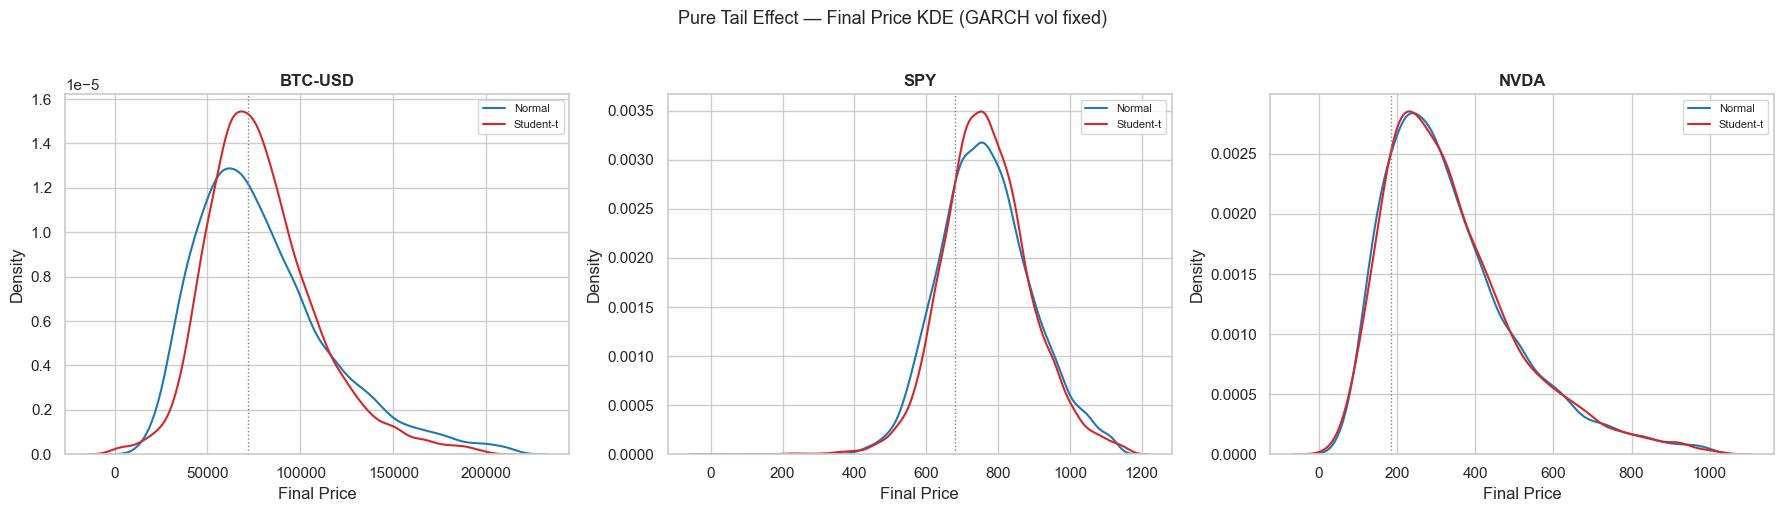

In [5]:
# KDE overlay: Normal vs Student-t final prices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"GARCH+Normal": "#1f77b4", "GARCH+Student-t": "#d62728"}

for ax, (ticker, results) in zip(axes, tail_results.items()):
    ip = assets[ticker]["initial_price"]
    for name, c in colors.items():
        # Trim at p99 for readability
        fp = results[name]["fp"]
        cutoff = fp.quantile(0.99)
        sns.kdeplot(fp[fp <= cutoff], ax=ax, label=name.split("+")[1], color=c, linewidth=1.5)
    ax.axvline(ip, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Final Price")
    ax.legend(fontsize=8)

fig.suptitle("Pure Tail Effect — Final Price KDE (GARCH vol fixed)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

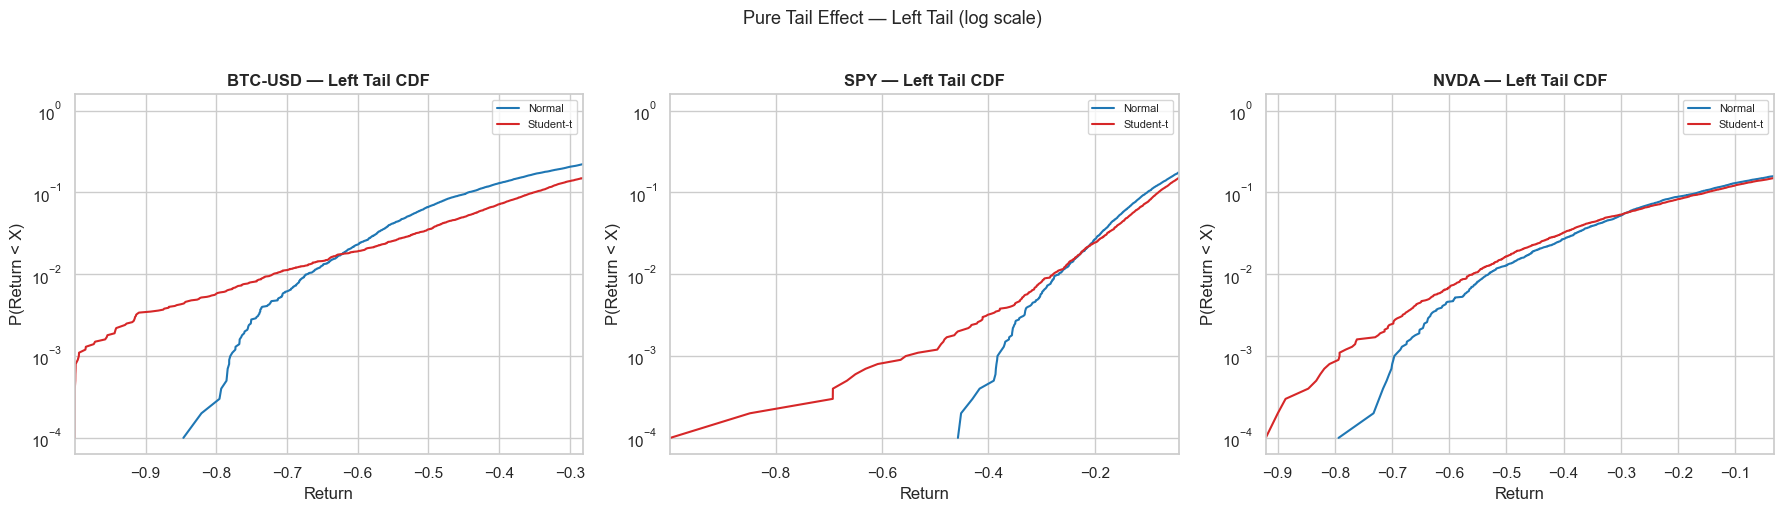

In [6]:
# Left-tail survival function (log scale) — where tail differences matter most
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (ticker, results) in zip(axes, tail_results.items()):
    ip = assets[ticker]["initial_price"]
    for name, c in colors.items():
        fp = results[name]["fp"]
        ret = ((fp - ip) / ip).sort_values()
        cdf = np.arange(1, len(ret) + 1) / len(ret)
        ax.plot(ret.values, cdf, label=name.split("+")[1], color=c, linewidth=1.5)
    ax.set_xlim(ret.quantile(0.0), ret.quantile(0.15))
    ax.set_yscale("log")
    ax.set_title(f"{ticker} — Left Tail CDF", fontweight="bold")
    ax.set_xlabel("Return")
    ax.set_ylabel("P(Return < X)")
    ax.legend(fontsize=8)

fig.suptitle("Pure Tail Effect — Left Tail (log scale)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Conclusion §2 — Pure tail effect.** At the 252-day horizon, switching from Normal to Student-t innovations under identical GARCH dynamics shifts the deep tail (VaR 99% / CVaR 99%) noticeably but barely moves the 95% quantile. Fat tails matter where you look for them; at the body of the distribution they are invisible. *(Full discussion: `docs/conclusions.md` §2.)*


## 3. Comparison 2 — Pure Vol Effect

**Fix innovation = Normal**, vary only the volatility model:
- Constant vol + Normal
- GARCH + Normal (forced via `innovation="normal"`)

This isolates the impact of time-varying volatility dynamics while keeping the tail shape identical.


In [7]:
vol_results = {}

for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    ip = data["initial_price"]
    garch_params = fit_garch(returns)

    configs = {
        "Constant+Normal": {"volatility_model": "constant"},
        "GARCH+Normal": {"volatility_model": "garch", "garch_params": garch_params, "innovation": "normal"},
    }

    vol_results[ticker] = {}
    for name, kwargs in configs.items():
        paths = simulate_paths(close, returns, n_days=N_DAYS, n_simulations=N_SIMS, seed=SEED, **kwargs)
        fp = paths.iloc[-1]
        s95 = simulation_summary(fp, ip, 0.95)
        s99 = simulation_summary(fp, ip, 0.99)
        vol_results[ticker][name] = {
            "var_95": s95["var"], "cvar_95": s95["cvar"],
            "var_99": s99["var"], "cvar_99": s99["cvar"],
            "prob_gain": s95["prob_gain"],
            "kurtosis": float(kurtosis(fp)),
            "fp": fp,
        }

print("Done.")

Done.


In [8]:
# Summary table: vol effect
rows = []
for ticker, results in vol_results.items():
    for name in ["Constant+Normal", "GARCH+Normal"]:
        r = results[name]
        rows.append({
            "Asset": ticker, "Vol Model": name.split("+")[0],
            "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
            "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
            "Kurtosis": f"{r['kurtosis']:.2f}",
        })

df_vol = pd.DataFrame(rows)
print("Pure Vol Effect (Normal shocks held constant):")
df_vol

Pure Vol Effect (Normal shocks held constant):


,Asset,Vol Model,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,Kurtosis
0,BTC-USD,Constant,-52.45%,-60.39%,-65.79%,-70.28%,3.91
1,BTC-USD,GARCH,-53.11%,-61.21%,-67.03%,-72.17%,5.68
2,SPY,Constant,-15.33%,-21.05%,-24.95%,-28.83%,0.34
3,SPY,GARCH,-15.67%,-22.20%,-26.73%,-31.97%,1.00
4,NVDA,Constant,-29.49%,-42.31%,-51.03%,-58.05%,5.13
5,NVDA,GARCH,-30.55%,-43.73%,-53.04%,-60.30%,6.66


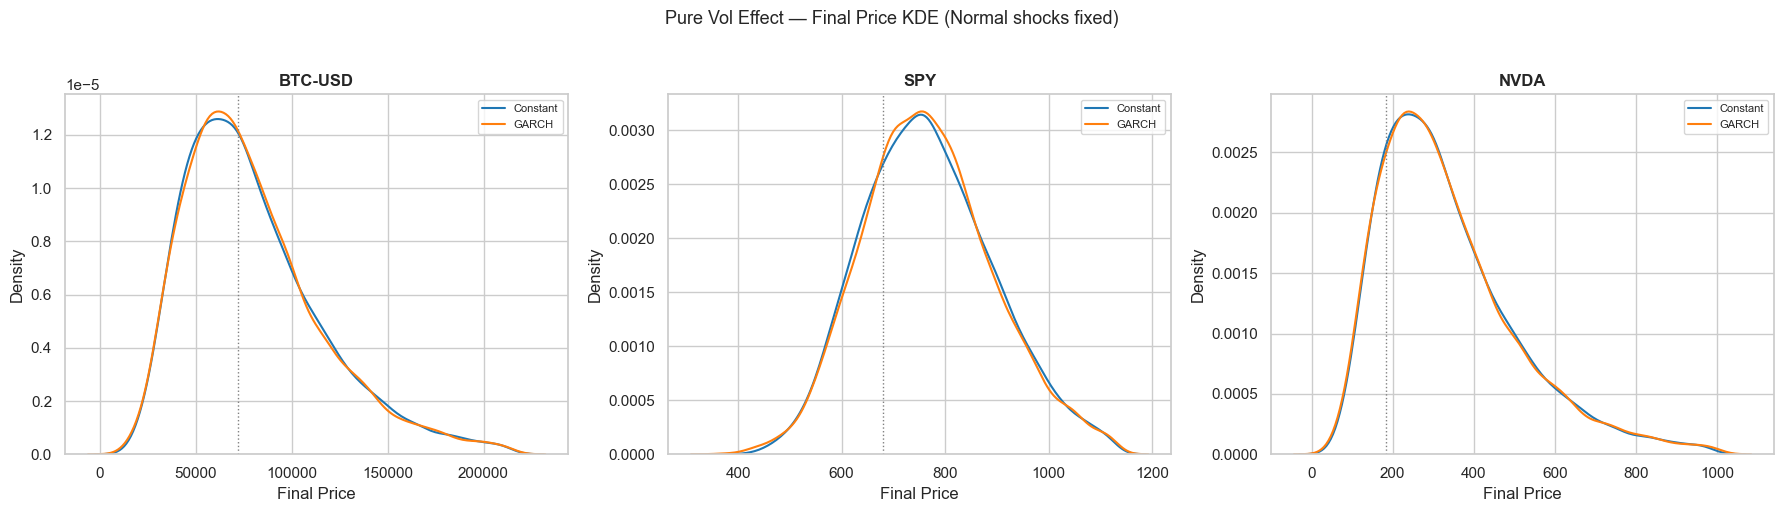

In [9]:
# KDE overlay: Constant vs GARCH (both Normal shocks)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_vol = {"Constant+Normal": "#1f77b4", "GARCH+Normal": "#ff7f0e"}

for ax, (ticker, results) in zip(axes, vol_results.items()):
    ip = assets[ticker]["initial_price"]
    for name, c in colors_vol.items():
        fp = results[name]["fp"]
        cutoff = fp.quantile(0.99)
        sns.kdeplot(fp[fp <= cutoff], ax=ax, label=name.split("+")[0], color=c, linewidth=1.5)
    ax.axvline(ip, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Final Price")
    ax.legend(fontsize=8)

fig.suptitle("Pure Vol Effect — Final Price KDE (Normal shocks fixed)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Conclusion §3 (252-day).** The vol signal dissolves at long horizons: GARCH mean-reverts to its long-run σ, so across 252 days the time-varying-vol distribution converges toward what a constant-σ model would produce. The per-asset differences below are small and not where the vol story lives. To actually see the vol effect we need a shorter horizon — see §3b.


## 3b. Pure Vol Effect Revisited — Why 21 Days?

The 252-day version above does not show the vol effect clearly. That is not a bug; it is the mathematics of GARCH mean-reversion. This section re-runs the same comparison at a **21-day** horizon. The choice is deliberate, not arbitrary.

**Why the vol effect dissolves at long horizons.** GARCH(1,1) is mean-reverting: after a shock, conditional variance decays geometrically back toward the long-run variance $\sigma^2_{lr} = \omega / (1 - \alpha - \beta)$. The half-life of a shock is $\ln(0.5) / \ln(\alpha + \beta)$ — for typical equity GARCH fits with persistence ≈ 0.97, that is roughly 23 days. By the time 252 days have elapsed, any individual simulated path has mean-reverted many half-lives, and the simulated distribution is dominated by the unconditional variance — exactly the quantity a constant-vol model uses from day one. The two models converge **by construction** at long horizons.

**Why 21 days specifically.**

1. **Basel monthly analogue.** 21 trading days ≈ one calendar month, the standard monthly regulatory window. Short enough that GARCH persistence still matters, long enough that a single shock does not dominate the sample.
2. **The vol signal has not yet been washed out.** At 21 days with persistence 0.97, a shock has decayed by roughly $0.97^{21} \approx 0.52$ — still half of its initial magnitude. Time-varying dynamics are still economically meaningful.
3. **Not cherry-picked.** The companion notebook [`horizon_crossover.ipynb`](horizon_crossover.ipynb) (see [RL-038](../docs/tickets/RL-038.md) and [`reports/horizon_crossover_results.md`](../reports/horizon_crossover_results.md)) maps the horizon at which MS-GARCH+EVT overtakes GARCH+t in VaR depth for each asset: BTC ≈ 63d, NVDA ≈ 126d, SPY ≈ 5d (oscillating). **All three crossovers sit at or above 21 days**, which means at 21d every asset is still in the "vol-dominant" regime — the regime where vol dynamics (not tail shape) drive the VaR differences. That is exactly the regime we want to be in to isolate the vol effect, which is what this comparison claims to do.

**What the result below should look like.** The GARCH and Constant curves should visibly separate — especially on BTC, where persistence is highest and shocks are largest.


Done.
Pure Vol Effect (Normal shocks held constant):


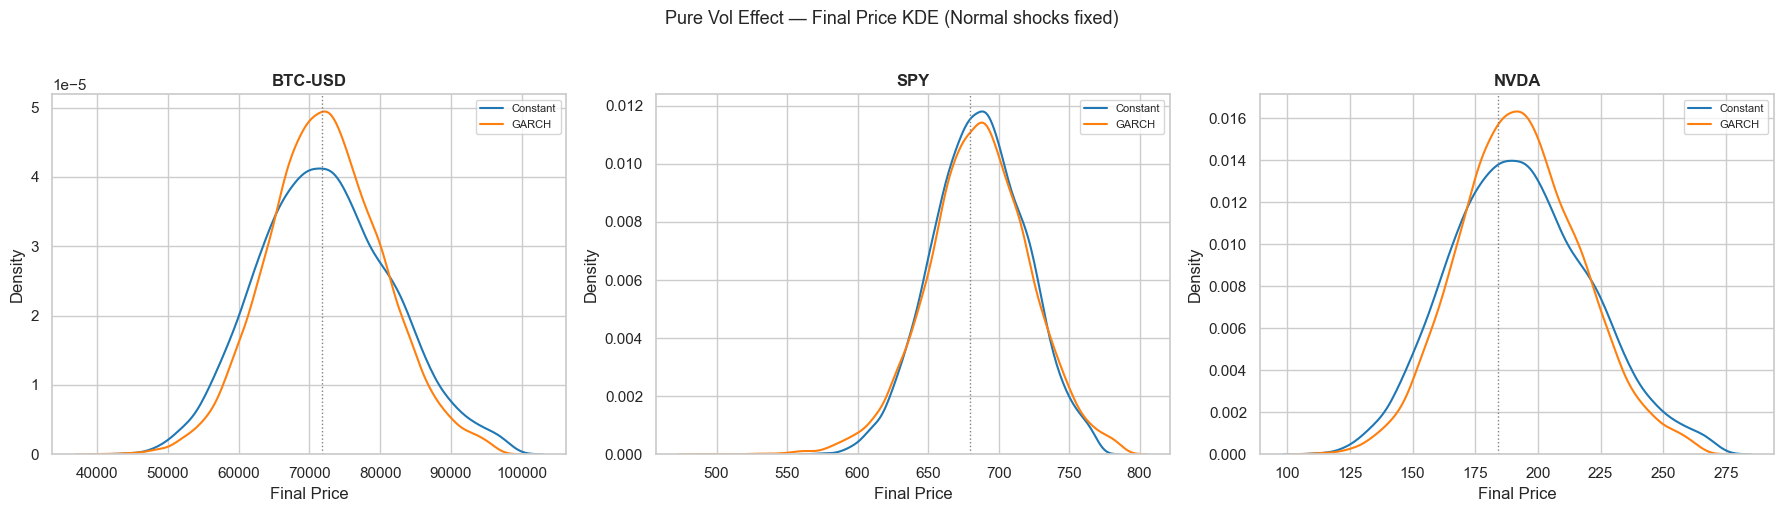

In [10]:
vol_results = {}

for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    ip = data["initial_price"]
    garch_params = fit_garch(returns)

    configs = {
        "Constant+Normal": {"volatility_model": "constant"},
        "GARCH+Normal": {"volatility_model": "garch", "garch_params": garch_params, "innovation": "normal"},
    }

    vol_results[ticker] = {}
    for name, kwargs in configs.items():
        paths = simulate_paths(close, returns, n_days=21, n_simulations=N_SIMS, seed=SEED, **kwargs)
        fp = paths.iloc[-1]
        s95 = simulation_summary(fp, ip, 0.95)
        s99 = simulation_summary(fp, ip, 0.99)
        vol_results[ticker][name] = {
            "var_95": s95["var"], "cvar_95": s95["cvar"],
            "var_99": s99["var"], "cvar_99": s99["cvar"],
            "prob_gain": s95["prob_gain"],
            "kurtosis": float(kurtosis(fp)),
            "fp": fp,
        }

print("Done.")

# Summary table: vol effect
rows = []
for ticker, results in vol_results.items():
    for name in ["Constant+Normal", "GARCH+Normal"]:
        r = results[name]
        rows.append({
            "Asset": ticker, "Vol Model": name.split("+")[0],
            "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
            "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
            "Kurtosis": f"{r['kurtosis']:.2f}",
        })

df_vol = pd.DataFrame(rows)
print("Pure Vol Effect (Normal shocks held constant):")
df_vol

# KDE overlay: Constant vs GARCH (both Normal shocks)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_vol = {"Constant+Normal": "#1f77b4", "GARCH+Normal": "#ff7f0e"}

for ax, (ticker, results) in zip(axes, vol_results.items()):
    ip = assets[ticker]["initial_price"]
    for name, c in colors_vol.items():
        fp = results[name]["fp"]
        cutoff = fp.quantile(0.99)
        sns.kdeplot(fp[fp <= cutoff], ax=ax, label=name.split("+")[0], color=c, linewidth=1.5)
    ax.axvline(ip, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Final Price")
    ax.legend(fontsize=8)

fig.suptitle("Pure Vol Effect — Final Price KDE (Normal shocks fixed)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Conclusion §3b — Pure vol effect (21-day).** With the horizon shortened enough that GARCH has not yet mean-reverted, time-varying vol produces visibly different tails than constant vol even with identical Normal shocks. The effect is largest on BTC (highest persistence, fattest historical tails) and smallest on SPY. **Vol dynamics are a short-horizon story; tail shape is a long-horizon story.** This split is what drives the horizon-dependent tier recommendation in the Streamlit app (see [RL-041](../docs/tickets/RL-041.md)). *(Full discussion: `docs/conclusions.md` §3.)*


## 4. Comparison 3 — The 3 Tiers Head-to-Head

The three models that will go into the app, each adding one layer of complexity:

| Tier | Volatility | Shocks | What it captures |
|------|-----------|--------|------------------|
| **Baseline** | Constant sigma | Normal | Symmetric risk, no clustering |
| **GARCH + Student-t** | Time-varying sigma | Student-t | Vol clustering + fat tails |
| **MS-GARCH + EVT** | Regime-switching GARCH | GPD tails | Regime changes + extreme tails |


In [11]:
tier_results = {}

for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    ip = data["initial_price"]

    garch_params = fit_garch(returns)
    ms_params = fit_ms_garch(returns, n_regimes=2, seed=SEED)

    tier_configs = {
        "Baseline": {"volatility_model": "constant"},
        "GARCH+t": {"volatility_model": "garch", "garch_params": garch_params},
        "MS-GARCH+EVT": {"volatility_model": "ms_garch", "ms_garch_params": ms_params},
    }

    tier_results[ticker] = {"ms_params": ms_params}
    for name, kwargs in tier_configs.items():
        paths = simulate_paths(close, returns, n_days=N_DAYS, n_simulations=N_SIMS, seed=SEED, **kwargs)
        fp = paths.iloc[-1]
        sim_returns = (fp - ip) / ip
        s95 = simulation_summary(fp, ip, 0.95)
        s99 = simulation_summary(fp, ip, 0.99)
        tier_results[ticker][name] = {
            "var_95": s95["var"], "cvar_95": s95["cvar"],
            "var_99": s99["var"], "cvar_99": s99["cvar"],
            "prob_gain": s95["prob_gain"],
            "kurtosis": float(kurtosis(fp)),
            "p_loss_30": float((sim_returns < -0.30).mean()),
            "p_loss_50": float((sim_returns < -0.50).mean()),
            "paths": paths,
            "fp": fp,
        }

    print(f"{ticker} — 3 tiers simulated")

print("\nDone.")

BTC-USD — 3 tiers simulated
SPY — 3 tiers simulated
NVDA — 3 tiers simulated

Done.


In [12]:
# Summary table: 3 tiers across 3 assets
rows = []
tier_names = ["Baseline", "GARCH+t", "MS-GARCH+EVT"]

for ticker in TICKERS:
    for name in tier_names:
        r = tier_results[ticker][name]
        rows.append({
            "Asset": ticker, "Tier": name,
            "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
            "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
            "P(Gain)": f"{r['prob_gain']:.1%}",
            "P(Loss>30%)": f"{r['p_loss_30']:.1%}",
            "P(Loss>50%)": f"{r['p_loss_50']:.1%}",
            "Kurtosis": f"{r['kurtosis']:.2f}",
        })

df_tiers = pd.DataFrame(rows)
print("3 Tiers x 3 Assets — Full Comparison:")
df_tiers

3 Tiers x 3 Assets — Full Comparison:


,Asset,Tier,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,P(Gain),P(Loss>30%),P(Loss>50%),Kurtosis
0,BTC-USD,Baseline,-52.45%,-60.39%,-65.79%,-70.28%,52.1%,21.2%,6.4%,3.91
1,BTC-USD,GARCH+t,-44.99%,-60.39%,-71.88%,-84.37%,56.1%,13.8%,3.5%,42.03
2,BTC-USD,MS-GARCH+EVT,-62.54%,-71.26%,-76.80%,-81.63%,47.0%,27.9%,12.4%,9.69
3,SPY,Baseline,-15.33%,-21.05%,-24.95%,-28.83%,74.6%,0.3%,0.0%,0.34
4,SPY,GARCH+t,-13.72%,-22.80%,-27.69%,-38.56%,78.2%,0.8%,0.1%,10.17
5,SPY,MS-GARCH+EVT,-21.94%,-37.43%,-45.71%,-62.43%,79.0%,3.0%,0.7%,1.62
6,NVDA,Baseline,-29.49%,-42.31%,-51.03%,-58.05%,83.0%,4.9%,1.1%,5.13
7,NVDA,GARCH+t,-32.06%,-46.81%,-55.87%,-65.78%,83.6%,5.3%,1.7%,37.70
8,NVDA,MS-GARCH+EVT,-61.72%,-79.89%,-91.09%,-96.27%,78.4%,11.9%,7.2%,4.59


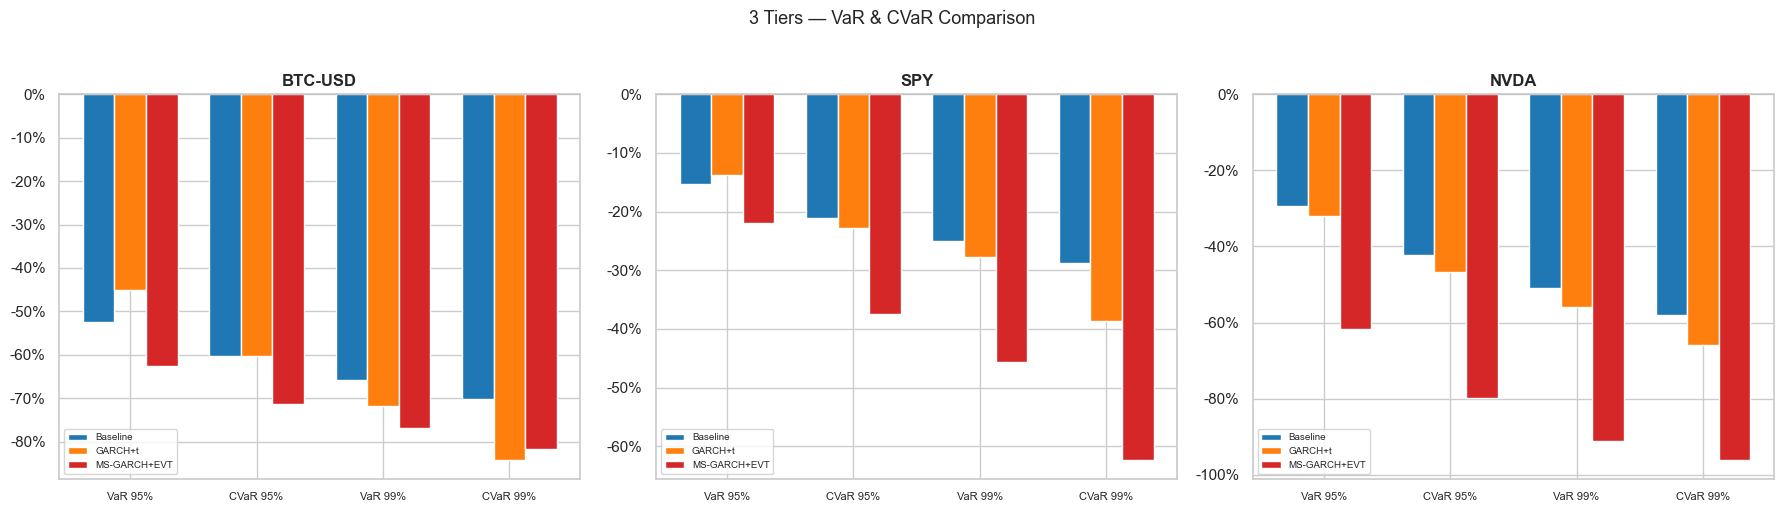

In [13]:
# VaR comparison bar chart per asset
tier_colors = {"Baseline": "#1f77b4", "GARCH+t": "#ff7f0e", "MS-GARCH+EVT": "#d62728"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["var_95", "cvar_95", "var_99", "cvar_99"]
metric_labels = ["VaR 95%", "CVaR 95%", "VaR 99%", "CVaR 99%"]

for ax, ticker in zip(axes, TICKERS):
    x = np.arange(len(metrics))
    width = 0.25
    for i, (name, c) in enumerate(tier_colors.items()):
        vals = [tier_results[ticker][name][m] for m in metrics]
        ax.bar(x + i * width, vals, width, label=name, color=c)
    ax.set_xticks(x + width)
    ax.set_xticklabels(metric_labels, fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", linewidth=0.5)

fig.suptitle("3 Tiers — VaR & CVaR Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

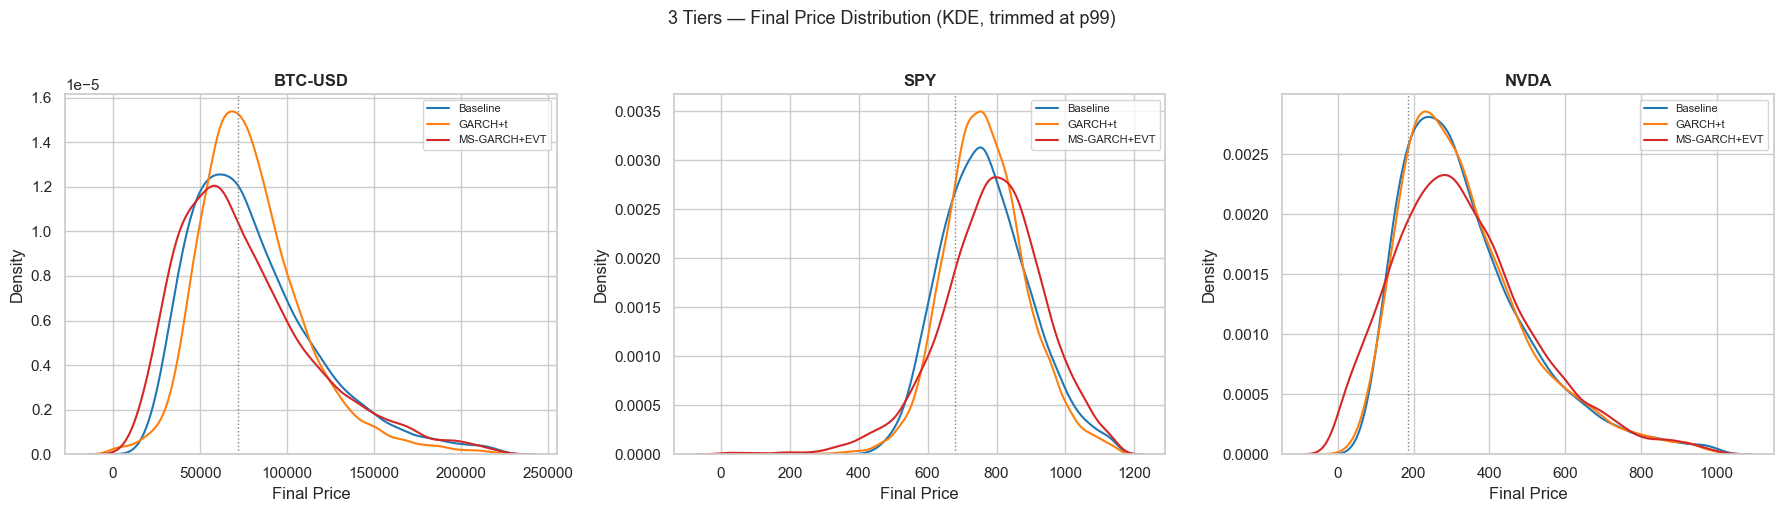

In [14]:
# KDE overlay per asset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, TICKERS):
    ip = assets[ticker]["initial_price"]
    all_fps = [tier_results[ticker][n]["fp"] for n in tier_names]
    cutoff = pd.concat(all_fps).quantile(0.99)
    for name, c in tier_colors.items():
        fp = tier_results[ticker][name]["fp"]
        sns.kdeplot(fp[fp <= cutoff], ax=ax, label=name, color=c, linewidth=1.5)
    ax.axvline(ip, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker}", fontweight="bold")
    ax.set_xlabel("Final Price")
    ax.legend(fontsize=8)

fig.suptitle("3 Tiers — Final Price Distribution (KDE, trimmed at p99)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

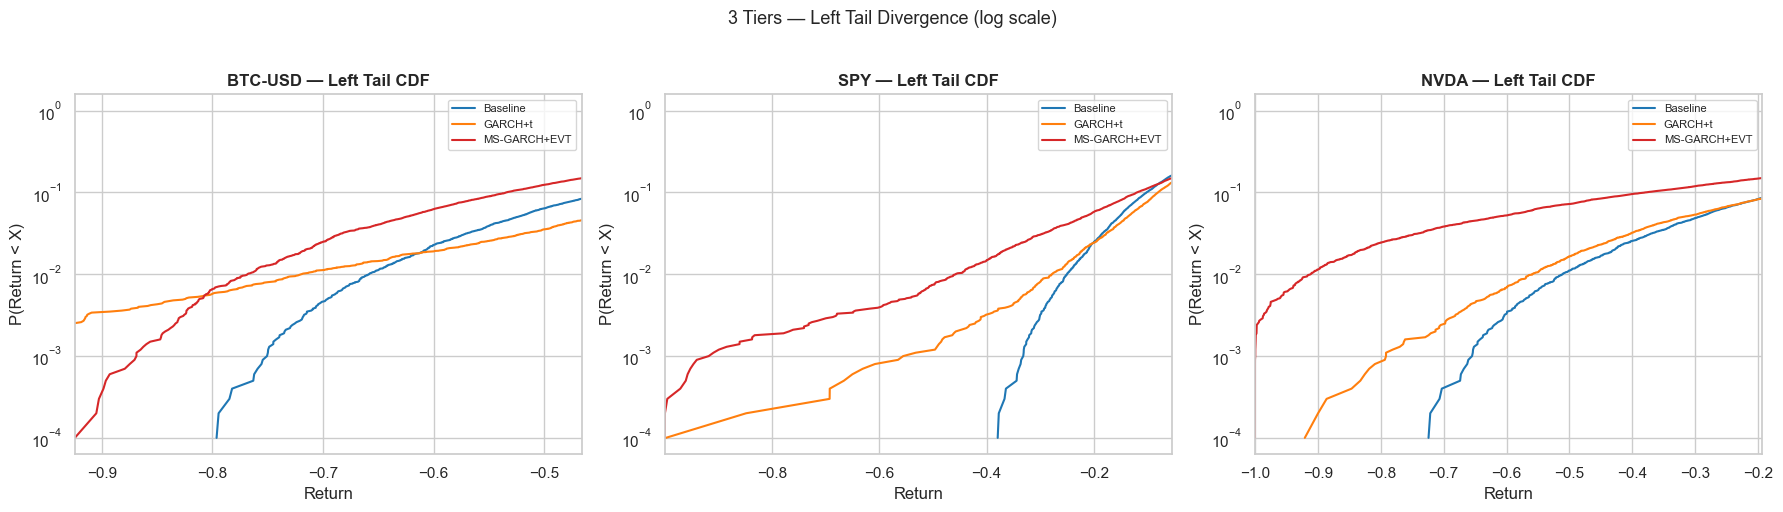

In [15]:
# Left-tail survival: where the 3 tiers diverge
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, TICKERS):
    ip = assets[ticker]["initial_price"]
    for name, c in tier_colors.items():
        fp = tier_results[ticker][name]["fp"]
        ret = ((fp - ip) / ip).sort_values()
        cdf = np.arange(1, len(ret) + 1) / len(ret)
        ax.plot(ret.values, cdf, label=name, color=c, linewidth=1.5)
    ax.set_xlim(ret.quantile(0.0), ret.quantile(0.15))
    ax.set_yscale("log")
    ax.set_title(f"{ticker} — Left Tail CDF", fontweight="bold")
    ax.set_xlabel("Return")
    ax.set_ylabel("P(Return < X)")
    ax.legend(fontsize=8)

fig.suptitle("3 Tiers — Left Tail Divergence (log scale)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

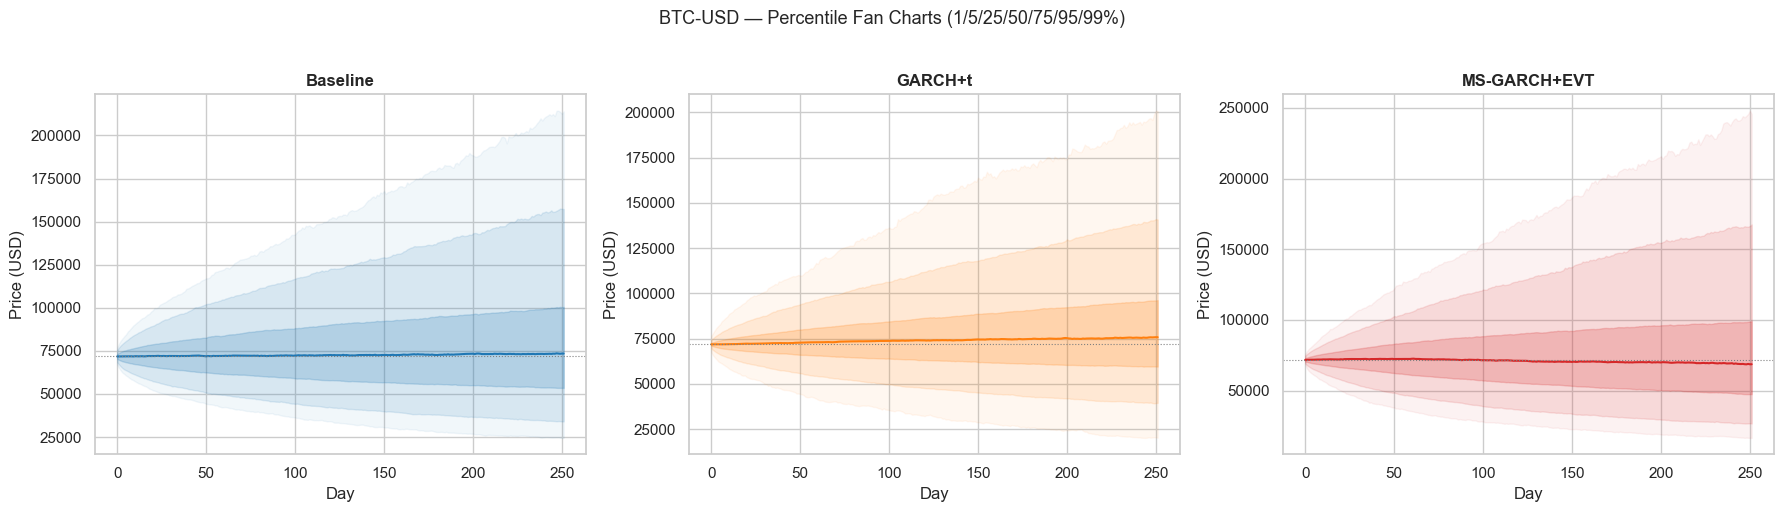

In [16]:
# Percentile fan chart for one asset (BTC — most interesting tails)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

for ax, (name, c) in zip(axes, tier_colors.items()):
    paths = tier_results["BTC-USD"][name]["paths"]
    pcts = {q: paths.quantile(q, axis=1) for q in quantiles}
    x = paths.index
    ax.fill_between(x, pcts[0.01], pcts[0.99], color=c, alpha=0.06)
    ax.fill_between(x, pcts[0.05], pcts[0.95], color=c, alpha=0.12)
    ax.fill_between(x, pcts[0.25], pcts[0.75], color=c, alpha=0.20)
    ax.plot(x, pcts[0.50], color=c, linewidth=1.5)
    ax.axhline(assets["BTC-USD"]["initial_price"], color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("Day")
    ax.set_ylabel("Price (USD)")

fig.suptitle("BTC-USD — Percentile Fan Charts (1/5/25/50/75/95/99%)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Conclusion §4 — 3 tiers head-to-head (252-day).** At long horizon MS-GARCH+EVT produces the deepest VaR on BTC and NVDA, GARCH+t sits in the middle, Baseline is shallowest. On SPY the ranking oscillates across confidence levels — the tail gain from EVT is small when the historical tail is already thin. **"Deepest VaR" is not the same as "best calibrated"** — that question is answered in `validation_backtesting.ipynb`. *(Full discussion: `docs/conclusions.md` §4.)*


## 4b. Seed Robustness — Are These Estimates Stable?

Single-seed point estimates can be misleading, especially for heavy-tailed distributions (BTC GARCH+t kurtosis ~80). Run each tier across 10 seeds and check how much VaR/CVaR varies.


In [17]:
from src.analytics.seed_robustness import run_multi_seed, robustness_summary

SEEDS = list(range(0, 100, 10))  # 10 seeds

seed_results = {}
for ticker, data in assets.items():
    close, returns = data["close"], data["returns"]
    garch_params = fit_garch(returns)
    ms_params = tier_results[ticker]["ms_params"]

    tier_configs = {
        "Baseline": {"volatility_model": "constant"},
        "GARCH+t": {"volatility_model": "garch", "garch_params": garch_params},
        "MS-GARCH+EVT": {"volatility_model": "ms_garch", "ms_garch_params": ms_params},
    }

    seed_results[ticker] = {}
    for name, kwargs in tier_configs.items():
        df = run_multi_seed(
            close, returns, n_days=N_DAYS, n_simulations=N_SIMS,
            seeds=SEEDS, **kwargs,
        )
        seed_results[ticker][name] = df
    print(f"{ticker} — seed robustness done")

print("Done.")

BTC-USD — seed robustness done
SPY — seed robustness done
NVDA — seed robustness done
Done.


In [18]:
# Summary table: stability per tier per asset
rows = []
for ticker in TICKERS:
    for name in ["Baseline", "GARCH+t", "MS-GARCH+EVT"]:
        s = robustness_summary(seed_results[ticker][name])
        rows.append({
            "Asset": ticker, "Tier": name,
            "VaR 95% (mean)": f"{s.loc['var_95%', 'mean']:.2%}",
            "VaR 95% (std)": f"{s.loc['var_95%', 'std']:.2%}",
            "VaR 95% (CV)": f"{s.loc['var_95%', 'cv']:.1%}",
            "CVaR 99% (mean)": f"{s.loc['cvar_99%', 'mean']:.2%}",
            "CVaR 99% (std)": f"{s.loc['cvar_99%', 'std']:.2%}",
            "CVaR 99% (CV)": f"{s.loc['cvar_99%', 'cv']:.1%}",
        })

df_stability = pd.DataFrame(rows)
print("Seed Robustness — Coefficient of Variation (CV) across 10 seeds:")
print("CV < 5% = stable, 5-15% = moderate, >15% = unstable")
df_stability

Seed Robustness — Coefficient of Variation (CV) across 10 seeds:
CV < 5% = stable, 5-15% = moderate, >15% = unstable


,Asset,Tier,VaR 95% (mean),VaR 95% (std),VaR 95% (CV),CVaR 99% (mean),CVaR 99% (std),CVaR 99% (CV)
0,BTC-USD,Baseline,-52.40%,0.44%,0.8%,-70.08%,0.83%,1.2%
1,BTC-USD,GARCH+t,-46.40%,0.48%,1.0%,-82.49%,1.26%,1.5%
2,BTC-USD,MS-GARCH+EVT,-62.88%,0.47%,0.7%,-81.46%,0.71%,0.9%
3,SPY,Baseline,-15.31%,0.29%,1.9%,-28.71%,0.73%,2.5%
4,SPY,GARCH+t,-13.80%,0.40%,2.9%,-38.86%,1.38%,3.6%
5,SPY,MS-GARCH+EVT,-22.20%,0.52%,2.3%,-61.97%,1.68%,2.7%
6,NVDA,Baseline,-29.41%,0.72%,2.5%,-57.72%,1.30%,2.3%
7,NVDA,GARCH+t,-30.82%,1.11%,3.6%,-64.77%,1.74%,2.7%
8,NVDA,MS-GARCH+EVT,-62.17%,1.19%,1.9%,-96.46%,0.39%,0.4%


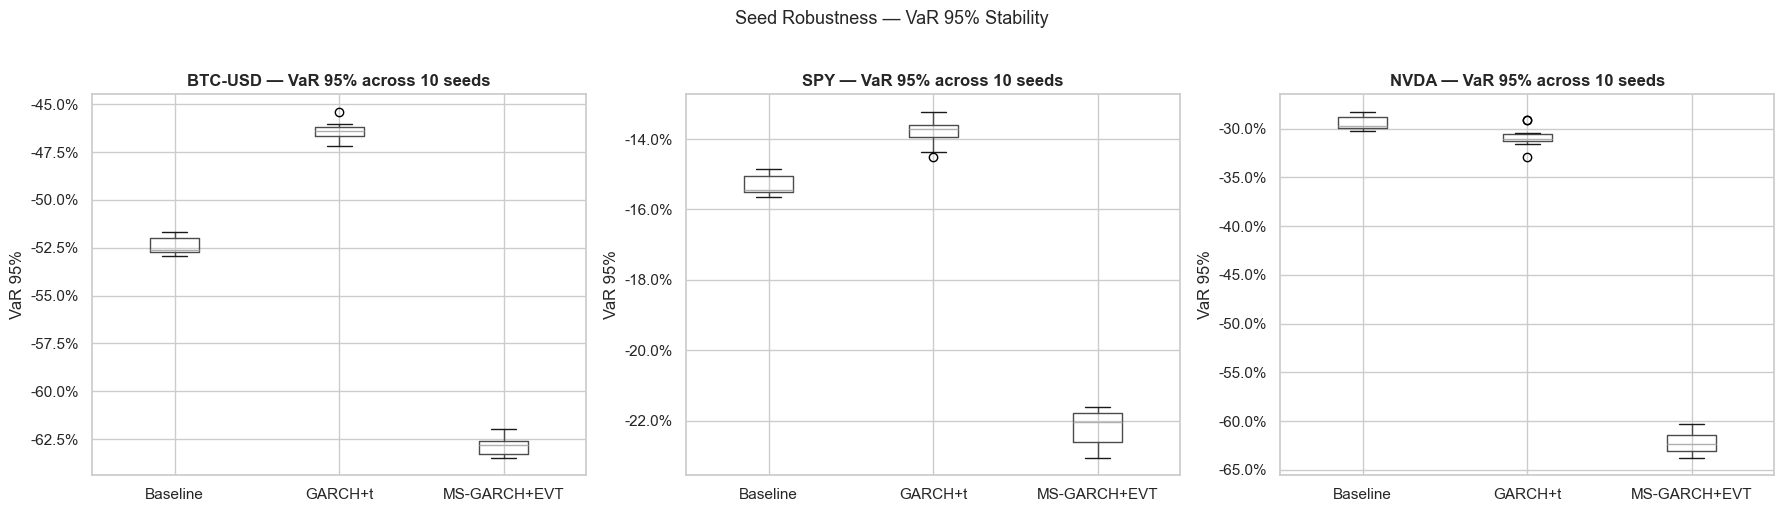

In [19]:
# Box plot: VaR 95% spread across seeds per tier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, TICKERS):
    plot_data = pd.DataFrame({
        name: seed_results[ticker][name]["var_95%"]
        for name in ["Baseline", "GARCH+t", "MS-GARCH+EVT"]
    })
    plot_data.boxplot(ax=ax)
    ax.set_title(f"{ticker} — VaR 95% across 10 seeds", fontweight="bold")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.set_ylabel("VaR 95%")

fig.suptitle("Seed Robustness — VaR 95% Stability", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Conclusion §4b — Seed robustness.** All three tiers are stable across 10 seeds (CV < 5% on every metric). MS-GARCH+EVT has the *lowest* spread, not the highest. But a low CV only means the Monte Carlo estimator has converged — it says **nothing** about whether the converged number is the right number. *Stability ≠ accuracy.* The backtest in NB2 is the accuracy test. *(Full discussion: `docs/conclusions.md` §4b; reusable module: [RL-031](../docs/tickets/RL-031.md) / `src/analytics/seed_robustness.py`.)*


## 5. MS-GARCH Model Details

Per-regime GARCH parameters and GPD tail shape for the top-tier model. After the RL-034 unified refit, α and β are shared across regimes (global GARCH); ω (and therefore σ_lr) is regime-specific via variance targeting; the GPD tail is fit per-regime on regime-filtered exceedances. See [`docs/decisions/ms_garch_unified.md`](../docs/decisions/ms_garch_unified.md) for the derivation.


In [20]:
for ticker in TICKERS:
    ms = tier_results[ticker]["ms_params"]
    print(f"\n{'='*60}")
    print(f"{ticker} — MS-GARCH (n_regimes={ms['n_regimes']})")
    print(f"{'='*60}")
    regime_names = {0: "Calm", 1: "Crisis"} if ms["n_regimes"] == 2 else {0: "Calm", 1: "Moderate", 2: "Crisis"}

    for k in range(ms["n_regimes"]):
        gp = ms["regime_garch"][k]
        gpd = ms["regime_gpd"][k]
        mu_k = ms["regime_mu"][k]
        marker = " <-- CURRENT" if k == ms["current_regime"] else ""
        print(f"\n  Regime {k} ({regime_names.get(k, f'R{k}')}){marker}:")
        print(f"    mu = {mu_k:.6f}")
        print(f"    GARCH: alpha={gp['alpha']:.4f}, beta={gp['beta']:.4f}, "
              f"persistence={gp['persistence']:.4f}, long_run_vol={gp['long_run_vol']:.2%}")
        if gpd is not None:
            print(f"    GPD: shape(xi)={gpd['shape']:.4f}, scale={gpd['scale']:.4f}, "
                  f"threshold={gpd['threshold']:.4f}, exceedances={gpd['n_exceedances']}")
        else:
            print(f"    GPD: None (Normal fallback)")

    print(f"\n  Transition matrix:")
    tm = ms["hmm_result"]["transition_matrix"]
    for i in range(ms["n_regimes"]):
        row = " ".join(f"{tm[i,j]:.3f}" for j in range(ms["n_regimes"]))
        print(f"    [{row}]")


BTC-USD — MS-GARCH (n_regimes=2)

  Regime 0 (Calm) <-- CURRENT:
    mu = 0.000521
    GARCH: alpha=0.0835, beta=0.8814, persistence=0.9648, long_run_vol=26.71%
    GPD: shape(xi)=-0.3269, scale=0.4884, threshold=1.1077, exceedances=73

  Regime 1 (Crisis):
    mu = 0.000564
    GARCH: alpha=0.0835, beta=0.8814, persistence=0.9648, long_run_vol=89.68%
    GPD: shape(xi)=-0.3205, scale=0.9206, threshold=2.7307, exceedances=19

  Transition matrix:
    [0.825 0.175]
    [0.380 0.620]

SPY — MS-GARCH (n_regimes=2)

  Regime 0 (Calm) <-- CURRENT:
    mu = 0.000916
    GARCH: alpha=0.1115, beta=0.8567, persistence=0.9682, long_run_vol=13.00%
    GPD: shape(xi)=-0.3446, scale=0.5713, threshold=1.3898, exceedances=53

  Regime 1 (Crisis):
    mu = -0.001481
    GARCH: alpha=0.1115, beta=0.8567, persistence=0.9682, long_run_vol=29.87%
    GPD: shape(xi)=0.8062, scale=0.2148, threshold=1.6024, exceedances=11

  Transition matrix:
    [0.994 0.006]
    [0.026 0.974]

NVDA — MS-GARCH (n_regimes=

> **Conclusion §5 — MS-GARCH internals.** The unified specification produces a single global persistence (α+β) with per-regime long-run vol. Crisis-regime σ_lr is typically 2–4× calm-regime σ_lr. Per-regime GPD may fall back to Normal when the crisis sample is too small (< 50 exceedances) — this is surfaced explicitly rather than silently ([RL-039](../docs/tickets/RL-039.md)). *(Full discussion: `docs/conclusions.md` §5.)*

---

**Next:** continue to [`validation_backtesting.ipynb`](validation_backtesting.ipynb) to see whether the deepest VaR is also the best-calibrated VaR.
